# Which warehouse serves each customer

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ula-uab/lscm-decision-making/blob/main/cases/warehouse_allocation/notebooks/warehouse_allocation.ipynb)

A company ships pallets from two warehouses, W1 and W2, to four customers, C1 to C4. Each week it decides which warehouse serves each customer. This is the running example of T1, and this notebook lets you play with it:

1. **Experience or a model?** You plan by hand, then compare with the rule of thumb and with the model.
2. **How many plans are there?** Few here, far too many in a real network.
3. **Two objectives.** Cost and delivery time pull in different directions.
4. **Uncertainty.** The plan rests on a forecast, and the forecast can be wrong.

**How to use it.** Run the cells in order, with ▶ or *Shift + Enter*. Some cells have a form (drop-down lists and sliders): change the values and run the cell again. Outside Colab the form is a line such as `C1 = "W1"`: edit the value and run the cell.

All the data and results are explained in the [document of the example](https://github.com/ula-uab/lscm-decision-making/blob/main/cases/warehouse_allocation/warehouse_allocation.md). Running the notebook is optional: it is support material, not part of the assessment.

In [1]:
# @title Setup (run this cell first) { display-mode: "form" }
# In Google Colab, install the example from GitHub (it takes a few seconds).
# On your own computer, install the repository environment instead (see README).
import sys
if "google.colab" in sys.modules:
    %pip install -q "git+https://github.com/ula-uab/lscm-decision-making#subdirectory=cases/warehouse_allocation"
import warehouses as wa

## 1. The situation

Each warehouse can ship a limited number of pallets per week, and each customer has a forecast demand. Shipping a pallet has a cost and takes some days, which depend on the warehouse and the customer. **Each customer is served entirely from one warehouse**: its order is not split.

The map is a sketch, not to scale: each customer is drawn nearer the warehouse that is cheaper and faster for it. Each link shows the cost per pallet and the delivery time.

,Capacity (pallets/week)
Warehouse,
W1,80
W2,70


,Forecast demand (pallets/week)
Customer,
C1,40
C2,30
C3,35
C4,25
Total,130


,C1,C2,C3,C4
Shipping cost (€/pallet),,,,
W1,2,3,2,6
W2,6,4,7,2


,C1,C2,C3,C4
Delivery time (days),,,,
W1,1,1,1,3
W2,2,4,3,1


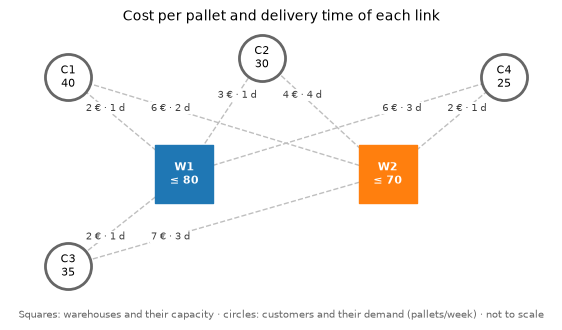

In [2]:
# @title Data and map { display-mode: "form" }
wa.show_data()

## 2. Be the planner

A **plan** says which warehouse serves each customer. Choose one below and run the cell. You will see:

- on the map, which warehouse serves each customer;
- the **load** of each warehouse, the pallets of the customers it serves, against its capacity: the load of $w$ is $\sum_{c} d_c\, x_{wc}$, where $d_c$ is the demand of customer $c$ and $x_{wc}$ is 1 if $w$ serves $c$ and 0 otherwise. A plan is **feasible** if no load goes over its capacity $K_w$;
- the **cost** of the plan: pallets × cost per pallet, added over all customers, $\sum_{w}\sum_{c} k_{wc}\, d_c\, x_{wc}$.

The plan proposed at first sends everything from W1. Change it and try to find a cheap plan that fits.

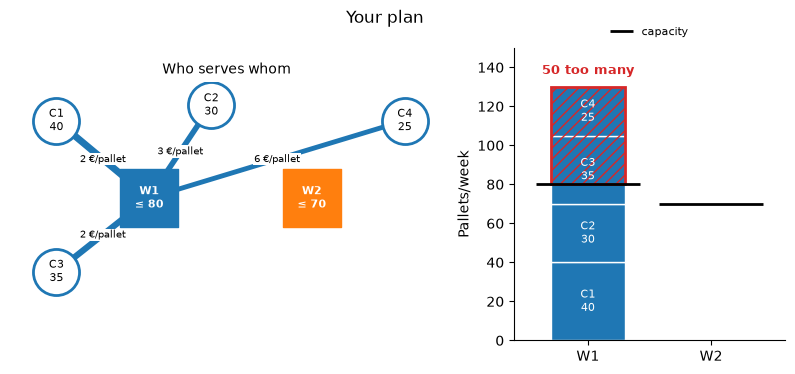

Your plan
  W1 ships 130 of 80 pallets (over capacity)
  W2 ships 0 of 70 pallets (70 spare)
  Cost: 390 €/week
  Average delivery time: 1.38 days
  Not feasible: over capacity in W1 by 50 pallets.


False

In [3]:
# @title Your plan { display-mode: "form" }
C1 = "W1"  # @param ["W1", "W2"]
C2 = "W1"  # @param ["W1", "W2"]
C3 = "W1"  # @param ["W1", "W2"]
C4 = "W1"  # @param ["W1", "W2"]
wa.check_plan({"C1": C1, "C2": C2, "C3": C3, "C4": C4})

## 3. Deciding from experience versus deciding with a model

**Rule of thumb.** An experienced planner serves each customer from its nearest warehouse: W1 for C1, C2 and C3, W2 for C4. It is also the cheapest and fastest link for each one. Does it fit?

**Diverting by hand.** When the nearest warehouse is full, a usual fix is to take the customers one by one, in order C1, C2, C3, C4, and send each one to its nearest warehouse if there is room left, or to the other one if not. This gives **plan M**.

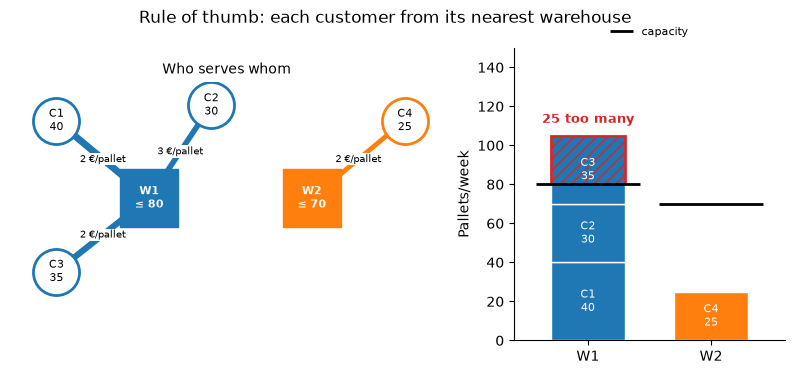

Rule of thumb: each customer from its nearest warehouse
  W1 ships 105 of 80 pallets (over capacity)
  W2 ships 25 of 70 pallets (45 spare)
  Cost: 290 €/week
  Average delivery time: 1.00 days
  Not feasible: over capacity in W1 by 25 pallets.



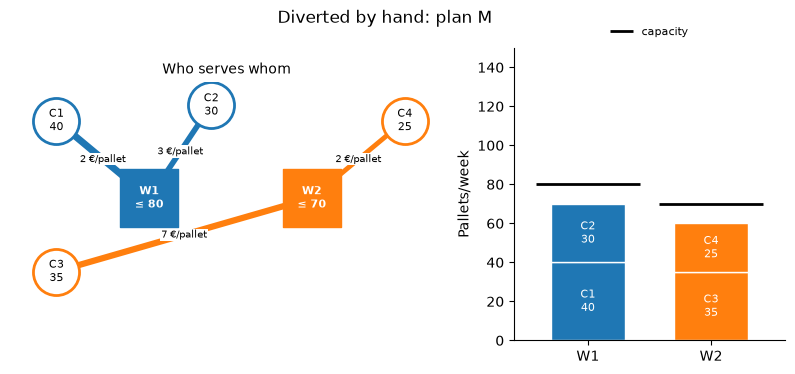

Diverted by hand: plan M
  W1 ships 70 of 80 pallets (10 spare)
  W2 ships 60 of 70 pallets (10 spare)
  Cost: 465 €/week
  Average delivery time: 1.54 days
  Feasible: every warehouse is within its capacity.


In [4]:
# @title Rule of thumb and plan M { display-mode: "form" }
wa.rule_of_thumb()

### Challenge: beat plan M

Plan M fits and costs 465 €/week. Can you find a feasible plan that costs less? The form starts from plan M.

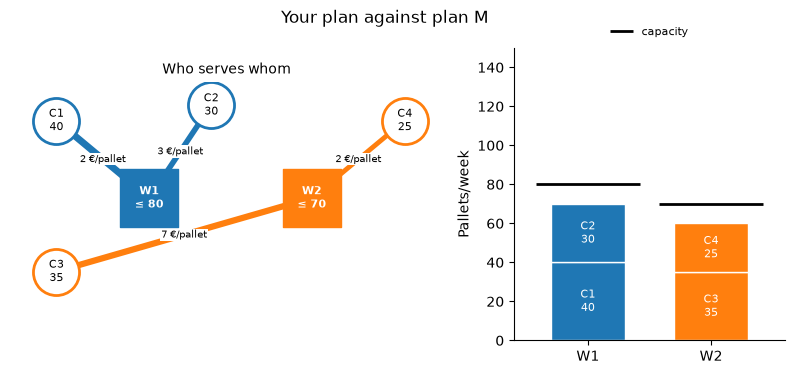

Your plan against plan M
  W1 ships 70 of 80 pallets (10 spare)
  W2 ships 60 of 70 pallets (10 spare)
  Cost: 465 €/week
  Average delivery time: 1.54 days
  Feasible: every warehouse is within its capacity.

Plan M costs 465 €/week; yours costs 465 €. Not better yet.
Hint: plan M diverts C3 because it happens to come last. Diverting a customer to W2
costs (cost from W2 - cost from W1) x pallets. Which customer is cheapest to divert?


In [5]:
# @title Beat plan M { display-mode: "form" }
C1 = "W1"  # @param ["W1", "W2"]
C2 = "W1"  # @param ["W1", "W2"]
C3 = "W2"  # @param ["W1", "W2"]
C4 = "W2"  # @param ["W1", "W2"]
wa.challenge({"C1": C1, "C2": C2, "C3": C3, "C4": C4})

### The model

The same problem, written in mathematical form. For each warehouse $w$ and customer $c$, the decision is $x_{wc} = 1$ if $w$ serves $c$, and $0$ otherwise. The model seeks the lowest total shipping cost:

$$
\begin{aligned}
\min \quad & \sum_{w \in W} \sum_{c \in C} k_{wc}\, d_c\, x_{wc} \\
\text{s.t.} \quad & \sum_{w \in W} x_{wc} = 1 && \forall c \in C && \text{(each customer from one warehouse)}\\
& \sum_{c \in C} d_c\, x_{wc} \le K_w && \forall w \in W && \text{(capacity)}\\
& x_{wc} \in \{0, 1\} && \forall w \in W,\ \forall c \in C
\end{aligned}
$$

The cell below writes these lines in Python with the library PuLP, and the solver HiGHS finds the best plan. The code is in the file `model.py` of the example, function `solve`: each line of the model is one line of code.

,C1,C2,C3,C4,Load W1,Load W2,Feasible,Cost (€/week),Average delivery time (days)
Plan,,,,,,,,,
M · diverted by hand,W1,W1,W2,W2,70,60,yes,465,1.54
A · model,W1,W2,W1,W2,75,55,yes,320,1.69


The model saves 145 €/week (31 % of the cost of plan M).
  Diverting C3 to W2 costs 5 € more per pallet on 35 pallets: 175 €/week.
  Diverting C2 to W2 costs 1 € more per pallet on 30 pallets: 30 €/week.


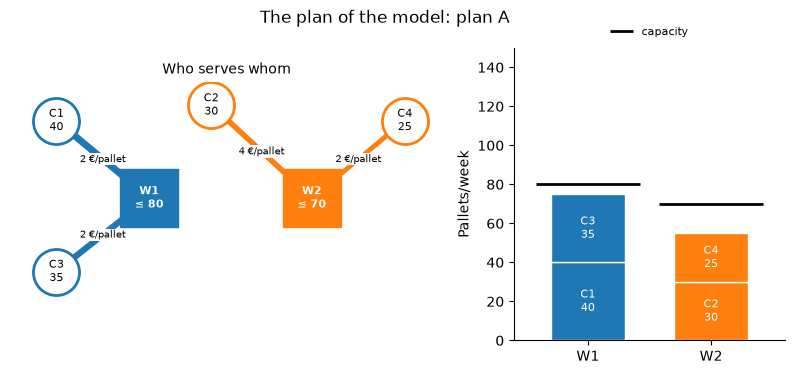

The plan of the model: plan A
  W1 ships 75 of 80 pallets (5 spare)
  W2 ships 55 of 70 pallets (15 spare)
  Cost: 320 €/week
  Average delivery time: 1.69 days
  Feasible: every warehouse is within its capacity.


In [6]:
# @title Solve the model { display-mode: "form" }
plan_A = wa.solve_model()

The model keeps C3 in W1 and diverts C2 instead. The rule of thumb diverts whichever customer happens to come last, not the one that is cheapest to divert. Did you find plan A in the challenge?

## 4. How many plans are there?

Each of the 4 customers can be served by either of the 2 warehouses: $2 \times 2 \times 2 \times 2 = 2^4 = 16$ plans. Only 5 of them fit in the warehouses.

In [7]:
# @title All 16 plans { display-mode: "form" }
wa.all_plans_table()

,C1,C2,C3,C4,Load W1,Load W2,Feasible,Cost (€/week),Average delivery time (days)
Plan,,,,,,,,,
A,W1,W2,W1,W2,75,55,yes,320,1.69
B,W2,W1,W1,W2,65,65,yes,450,1.31
M,W1,W1,W2,W2,70,60,yes,465,1.54
D,W2,W2,W1,W1,60,70,yes,580,2.38
E,W1,W2,W2,W1,65,65,yes,595,2.62
#6,W1,W1,W1,W2,105,25,no (W1),290,1.00
#7,W1,W1,W1,W1,130,0,no (W1),390,1.38
#8,W1,W2,W1,W1,100,30,no (W1),420,2.08
#9,W2,W2,W1,W2,35,95,no (W2),480,2.00


Sixteen plans can be checked by hand. With $m$ warehouses and $n$ customers there are $m^n$ plans. The table below assumes a computer that checks a billion plans per second, which is generous, and compares the time with the age of the universe, about 13.8 billion years (Planck Collaboration, 2020, *Astronomy & Astrophysics* 641, A6).

In [8]:
# @title The number of plans grows very fast { display-mode: "form" }
wa.explosion_table()

Plans Time to check them all  \
Warehouses Customers                                                    
2          4                                16     less than a second   
3          10                           59,049     less than a second   
5          30          a number with 21 digits           29,512 years   
10         50          a number with 51 digits          3.2e+33 years   
           200        a number with 201 digits         3.2e+183 years   

                     Times the age of the universe  
Warehouses Customers                                
2          4                                     —  
3          10                                    —  
5          30                                    —  
10         50                              2.3e+23  
           200                            2.3e+173

This is why checking every plan (*brute force*) is not a method, and why T2 studies optimisation methods. A solver does not list the plans: it finds the best one by reasoning on the model. Here both ways give the same plan.

In [9]:
# @title Brute force and solver { display-mode: "form" }
wa.compare_methods()

Checking all 16 plans: plan A, 320 €/week
Solver (PuLP + HiGHS): plan A, 320 €/week


## 5. Two objectives: cost and delivery time

Cost is not the only thing that matters. The **average delivery time** of a plan is the delivery time of each customer weighted by its pallets, $\sum_{w}\sum_{c} t_{wc}\, d_c\, x_{wc} \,/\, \sum_{c} d_c$, where $t_{wc}$ is the delivery time from $w$ to $c$.

The figure shows the 16 plans on both criteria. A plan is **Pareto-optimal** if no other feasible plan is at least as good on both criteria and better on one: those are the green ones. Plan A is the cheapest, but it serves C2 from W2, which takes 4 days.

To choose, the company must say **how much a faster delivery is worth**: how many euros per week it would pay to deliver, on average, one day earlier. With that value, each plan gets a single score, cost + value × average delivery time, and the best plan is the one with the lowest score. Move the slider and run the cell. This is one of several ways of handling two objectives; T3-T comes back to them.

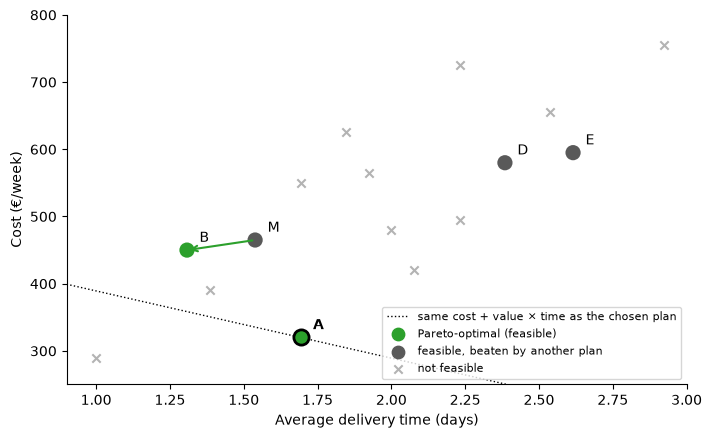

A day less of average delivery time is worth 100 €/week.
Best plan: A, 320 €/week and 1.69 days.
The choice changes from A to B at 338 €/week per day. For no value is M chosen: B beats it on both criteria (green arrow).


In [10]:
# @title How much is a day worth? { display-mode: "form" }
value_of_a_day = 100  # @param {type:"slider", min:0, max:1000, step:10}
wa.two_objectives(value_of_a_day)

## 6. Uncertainty: the forecast can be wrong

The plan uses the forecast demand. The forecast of C3 is the average of its last four weeks of orders (a 4-week moving average). Its error is orders − forecast, and it is summarised with:

- **MAE** (mean absolute error): the average size of the error, in pallets/week;
- **MAPE** (mean absolute percentage error): the same, as a percentage of the orders;
- **bias**: the average error with its sign; close to zero means the forecast is not systematically too high or too low.

Week,1,2,3,4,5,6,7,8,9,10,11,12
Orders,33.0,36.0,34.0,38.0,31.0,35.0,37.0,32.0,36.0,34.0,35.0,35.0
Forecast,—,—,—,—,35.25,34.75,34.5,35.25,33.75,35.0,34.75,34.25
Error (orders − forecast),—,—,—,—,-4.25,0.25,2.5,-3.25,2.25,-1.0,0.25,0.75


MAE 1.81 pallets/week · MAPE 5.4 % · bias -0.31 pallets/week (weeks 5-12)
Forecast for week 13: 35 pallets


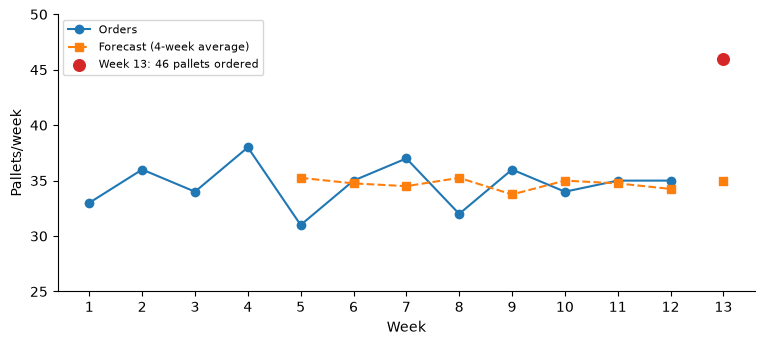

In [11]:
# @title Orders and forecast of C3 { display-mode: "form" }
wa.show_forecast()

### What if the error is large?

In week 13 the forecast of C3 is 35 pallets, but C3 orders 46. Does plan A still fit? Try other orders with the slider. The cell also **re-plans**: it solves the model again with the new order. In practice the plan is recomputed every week as new orders arrive, which is called planning with a rolling horizon (T3-P).

C3 orders 46 pallets; the forecast was 35 (+11).


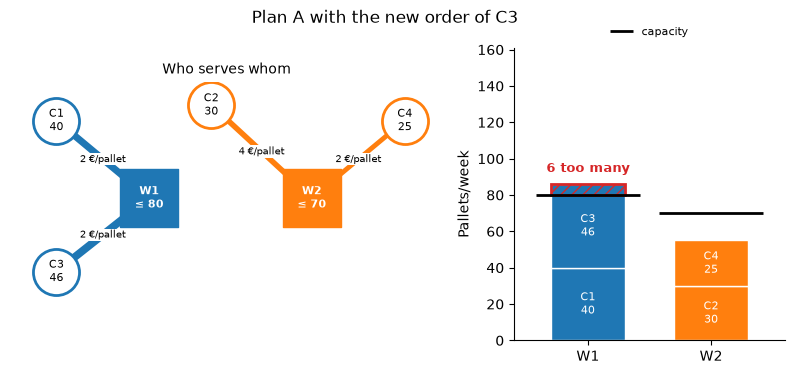

Plan A with the new order of C3
  This is plan A of Table 6.
  W1 ships 86 of 80 pallets (over capacity)
  W2 ships 55 of 70 pallets (15 spare)
  Cost: 342 €/week
  Not feasible: over capacity in W1 by 6 pallets.

Re-planning with the new order: the best plan is now B, at 472 €/week.


,C1,C2,C3,C4,Load W1,Load W2,Feasible,Cost (€/week),Average delivery time (days)
Plan,,,,,,,,,
Re-planned,W2,W1,W1,W2,76,65,yes,472,1.31


In [12]:
# @title A large error in week 13 { display-mode: "form" }
c3_order = 46  # @param {type:"slider", min:25, max:55, step:1}
wa.large_error(c3_order)

### What does a safety margin cost?

One way to protect the plan is to keep part of the capacity in reserve: with a 10 % reserve, W1 plans with 72 pallets instead of 80. The model then chooses the best plan with less capacity, and the margin costs money. The second figure shows whether that plan copes with the real order of C3 in week 13.

Try a reserve of 10 % and then of 7 %. Which one copes with the 46 pallets of C3? Why is more reserve not always more protection?

Reserve 10 %: W1 plans with 72 pallets, W2 with 63.
Best plan: M, 465 €/week. The margin costs 145 €/week.



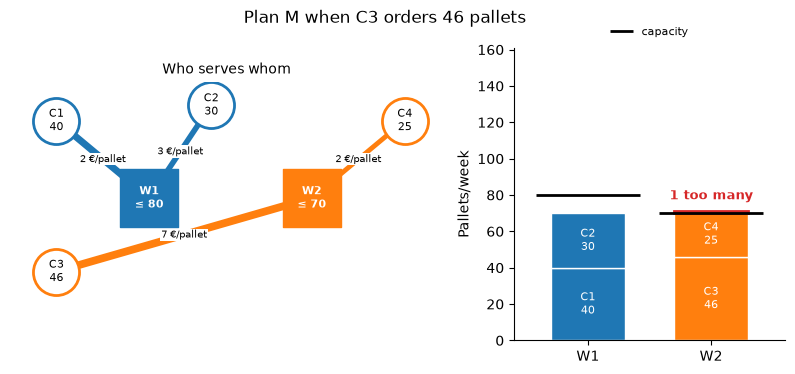

Plan M when C3 orders 46 pallets
  This is plan M of Table 6.
  W1 ships 70 of 80 pallets (10 spare)
  W2 ships 71 of 70 pallets (over capacity)
  Cost: 542 €/week
  Not feasible: over capacity in W2 by 1 pallet.


In [13]:
# @title A safety margin { display-mode: "form" }
reserve_percent = 10  # @param {type:"slider", min:0, max:15, step:1}
c3_order = 46  # @param {type:"slider", min:25, max:55, step:1}
wa.safety_margin(reserve_percent, c3_order)

## What to take away

- A model found a plan 145 €/week cheaper than the one diverted by hand, in a problem with only 16 plans.
- The number of plans grows so fast that real problems need optimisation methods (T2).
- With two objectives there is no single best plan, only a choice between Pareto-optimal plans (T3-T).
- A plan rests on a forecast. A large error can break it; a margin costs money and protects only where the spare room is. Re-planning every week is the usual answer (T3-P).

All the numbers are explained in the [document of the example](https://github.com/ula-uab/lscm-decision-making/blob/main/cases/warehouse_allocation/warehouse_allocation.md), which also has two scripts that reproduce them.